5 Data Teratas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


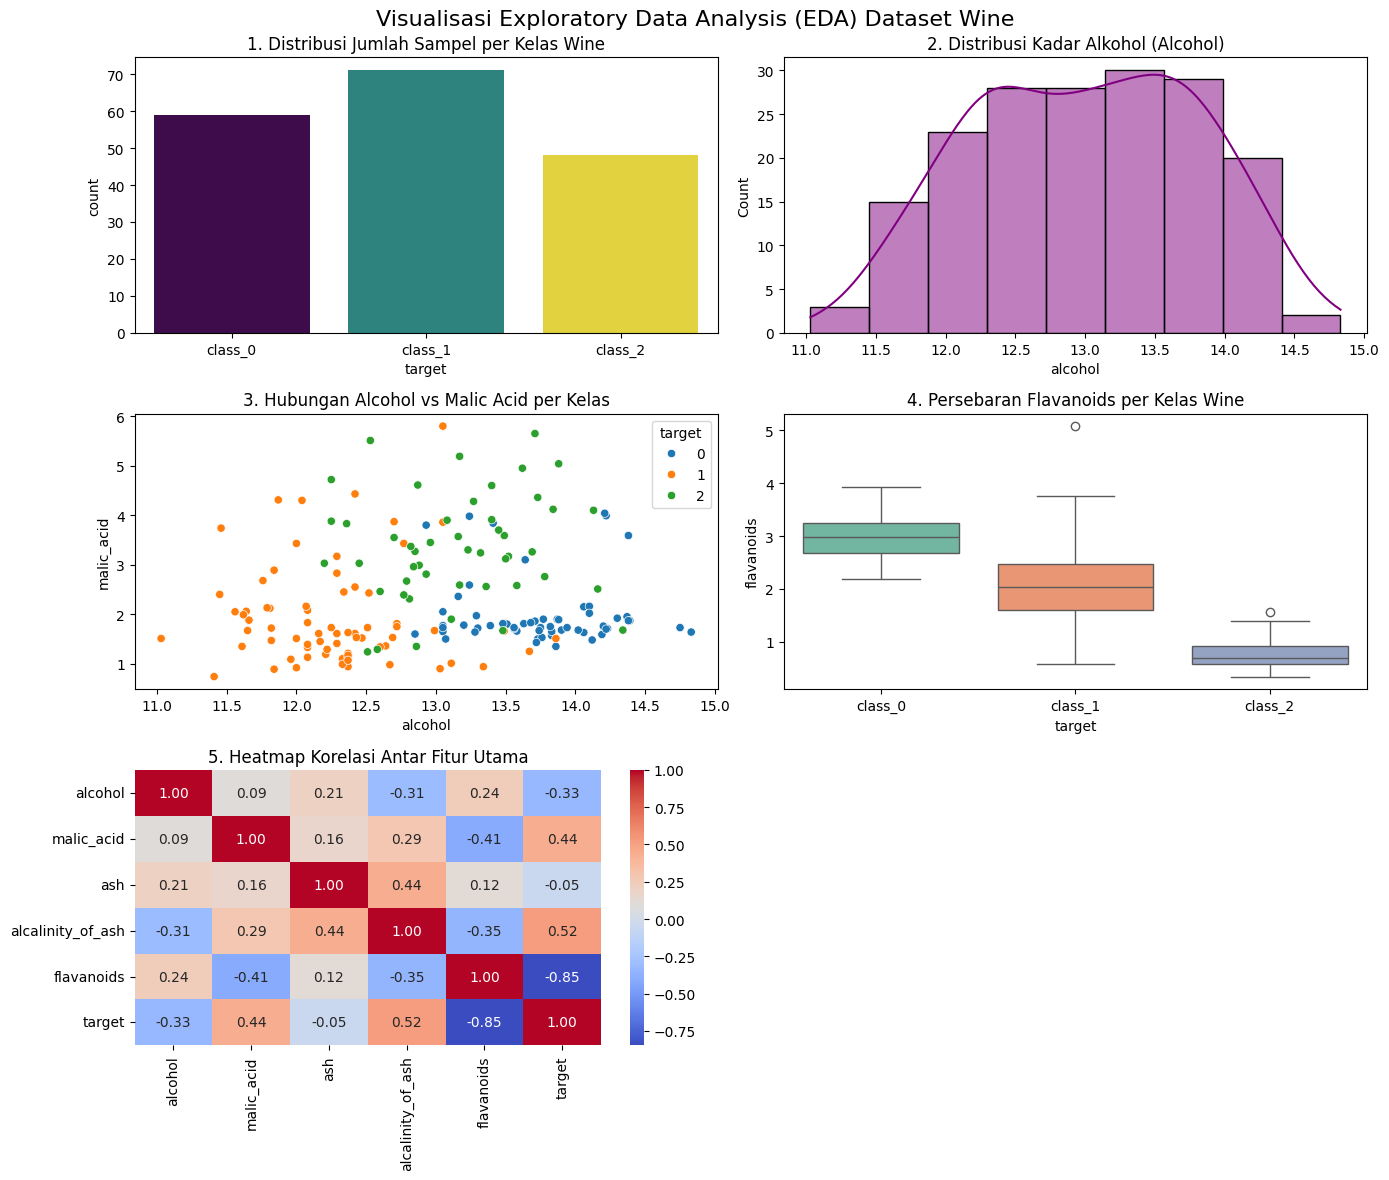

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset Wine
wine = load_wine(as_frame=True)
df = wine.frame

print("5 Data Teratas:")
display(df.head())

# Visualisasi Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Visualisasi Exploratory Data Analysis (EDA) Dataset Wine', fontsize=16)

# Visualisasi 1: Distribusi Target (Kelas Wine)
sns.countplot(ax=axes[0, 0], x='target', data=df, hue='target', palette='viridis', legend=False)
axes[0, 0].set_title('1. Distribusi Jumlah Sampel per Kelas Wine')
axes[0, 0].set_xticks(range(len(wine.target_names)))
axes[0, 0].set_xticklabels(wine.target_names)

# Visualisasi 2: Histogram Kadar Alkohol
sns.histplot(ax=axes[0, 1], data=df, x='alcohol', kde=True, color='purple')
axes[0, 1].set_title('2. Distribusi Kadar Alkohol (Alcohol)')

# Visualisasi 3: Scatter Plot Alcohol vs Malic Acid
sns.scatterplot(ax=axes[1, 0], data=df, x='alcohol', y='malic_acid', hue='target', palette='tab10')
axes[1, 0].set_title('3. Hubungan Alcohol vs Malic Acid per Kelas')

# Visualisasi 4: Boxplot Kadar Flavanoids per Kelas
sns.boxplot(ax=axes[1, 1], data=df, x='target', y='flavanoids', hue='target', palette='Set2', legend=False)
axes[1, 1].set_title('4. Persebaran Flavanoids per Kelas Wine')
axes[1, 1].set_xticks(range(len(wine.target_names)))
axes[1, 1].set_xticklabels(wine.target_names)

# Visualisasi 5: Heatmap Korelasi Sebagian Fitur
corr_features = df[['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'flavanoids', 'target']].corr()
sns.heatmap(ax=axes[2, 0], data=corr_features, annot=True, cmap='coolwarm', fmt=".2f")
axes[2, 0].set_title('5. Heatmap Korelasi Antar Fitur Utama')

# Sisa axes kosong disembunyikan
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Pemisahan Fitur (X) dan Target (y)
X = wine.data
y = wine.target

# Split data: 70% Train, 30% Test (dengan stratify agar proporsi kelas seimbang)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Inisialisasi dan pelatihan model KNN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     class_0       0.89      0.89      0.89        18
     class_1       0.78      0.67      0.72        21
     class_2       0.50      0.60      0.55        15

    accuracy                           0.72        54
   macro avg       0.72      0.72      0.72        54
weighted avg       0.74      0.72      0.73        54



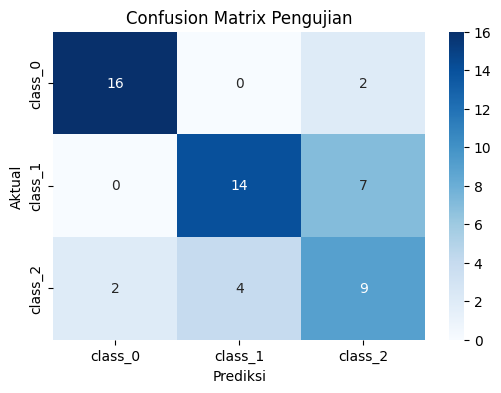

In [5]:
# Pengujian pada Data Test
y_pred = model.predict(X_test)

# Cetak Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Confusion Matrix Visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title('Confusion Matrix Pengujian')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()